# Explore here

In [16]:
# Paso 1: Carga del conjunto de datos
#Importamos las librerías necesarias y cargamos el dataset de seguros médicos directamente desde la URL.

# ── Importamos las librerías que vamos a necesitar en todo el proyecto ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Librerías importadas correctamente")

# ── URL del dataset ──
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"

# ── Cargamos el dataset en un DataFrame ──
df = pd.read_csv(url)

print("✅ Dataset cargado correctamente")
print(f"📊 Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()
# ── Información general del dataset ──
print("📋 Información del dataset:")
print("-" * 40)
df.info()


✅ Librerías importadas correctamente
✅ Dataset cargado correctamente
📊 Filas: 1338 | Columnas: 7
📋 Información del dataset:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [17]:
# ── Estadísticas descriptivas básicas ──
print("📊 Estadísticas descriptivas:")
df.describe()

# ── Comprobamos si hay valores nulos ──
print("🔍 Valores nulos por columna:")
print(df.isnull().sum())
print()

# ── Comprobamos si hay filas duplicadas ──
duplicados = df.duplicated().sum()
print(f"🔁 Filas duplicadas: {duplicados}")
print()

# ── Tipos de datos de cada columna ──
print("🏷️  Tipos de datos:")
print(df.dtypes)

📊 Estadísticas descriptivas:
🔍 Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

🔁 Filas duplicadas: 1

🏷️  Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


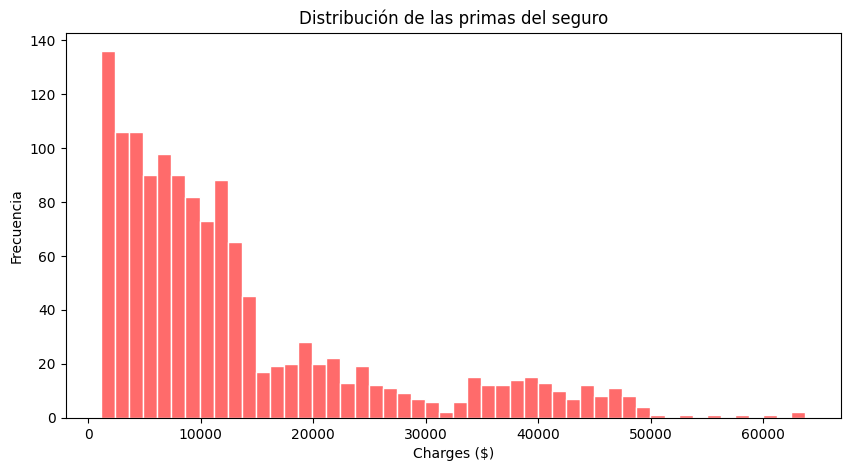

In [18]:
# distribucion de charges (lo que queremos predecir)
plt.figure(figsize=(10, 5))
plt.hist(df['charges'], bins=50, color='#FF6B6B', edgecolor='white')
plt.title('Distribución de las primas del seguro')
plt.xlabel('Charges ($)')
plt.ylabel('Frecuencia')
plt.show()

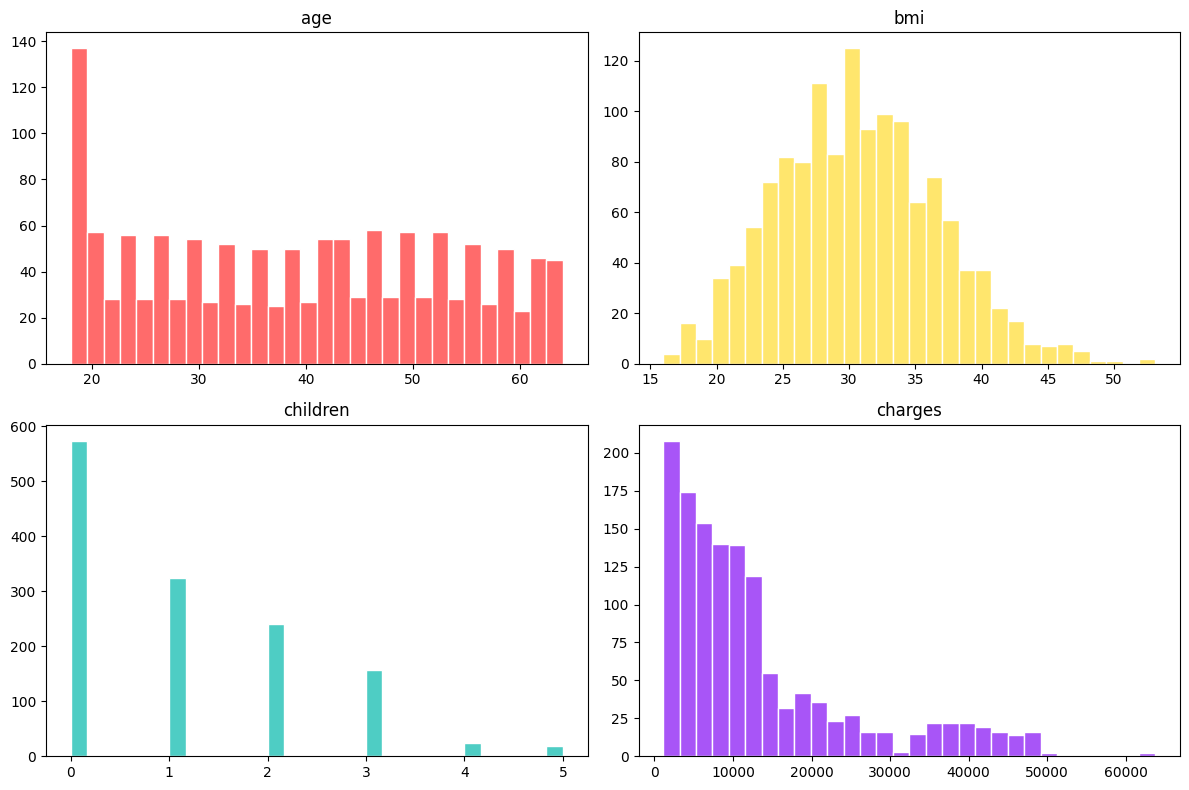

In [19]:
# histogramas de todas las variables numericas
colores = ['#FF6B6B', '#FFE66D', '#4ECDC4', '#A855F7']
numericas = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col], bins=30, color=colores[i], edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

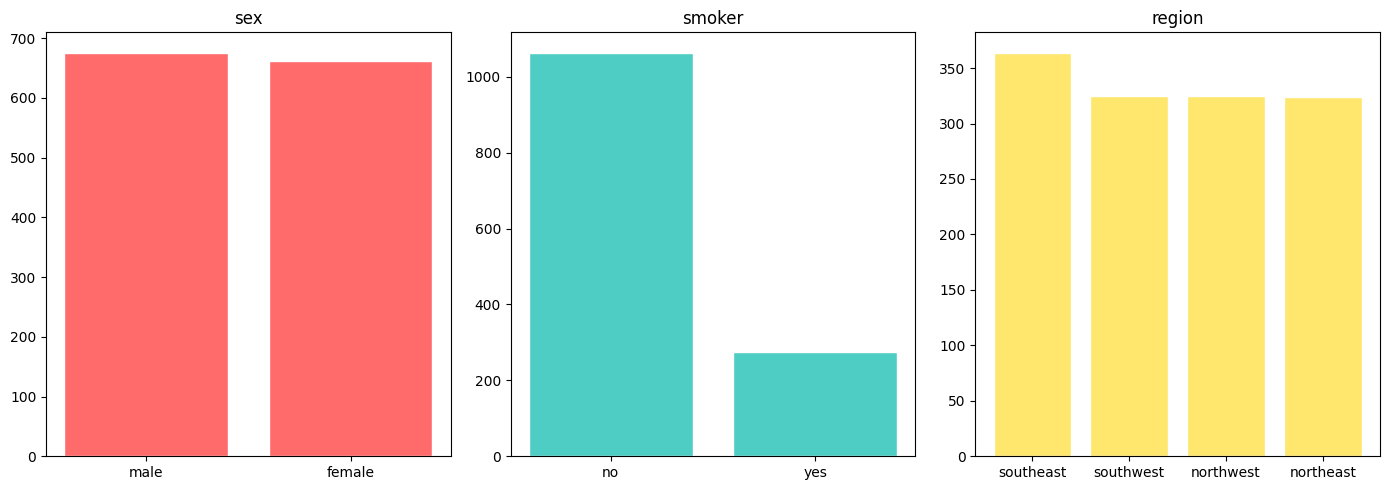

In [20]:
# conteo de variables categoricas
categoricas = ['sex', 'smoker', 'region']
colores_cat = ['#FF6B6B', '#4ECDC4', '#FFE66D']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categoricas):
    conteo = df[col].value_counts()
    axes[i].bar(conteo.index, conteo.values, color=colores_cat[i], edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

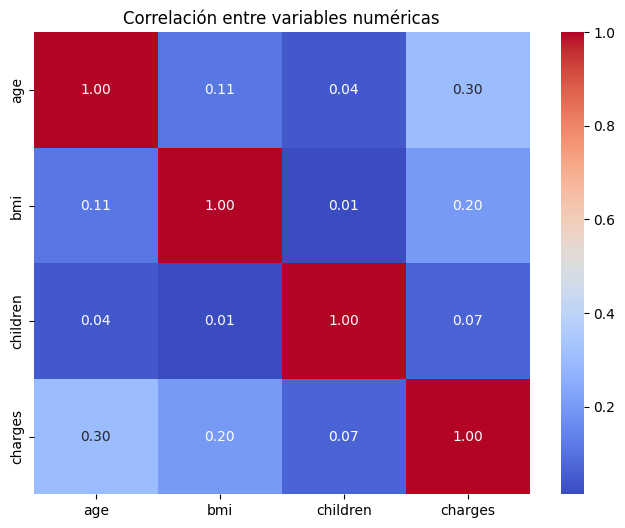

In [21]:
# mapa de correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

/tmp/ipykernel_852/1033406184.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df,


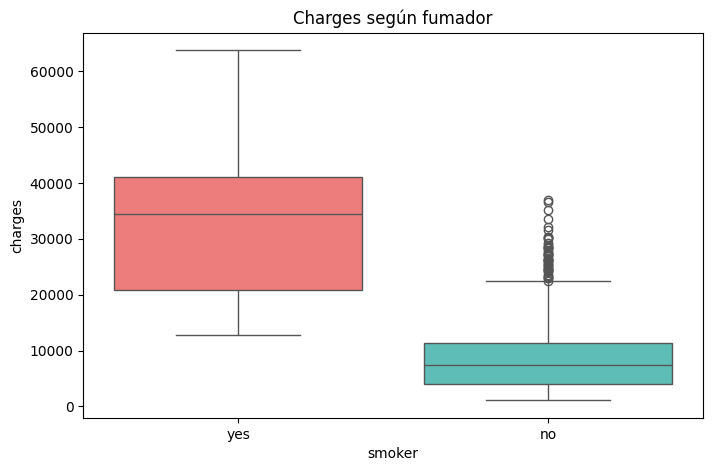

In [22]:
# como afecta ser fumador al precio
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df,
            palette={'yes': '#FF6B6B', 'no': '#4ECDC4'})
plt.title('Charges según fumador')
plt.show()

/tmp/ipykernel_852/3551455282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df,


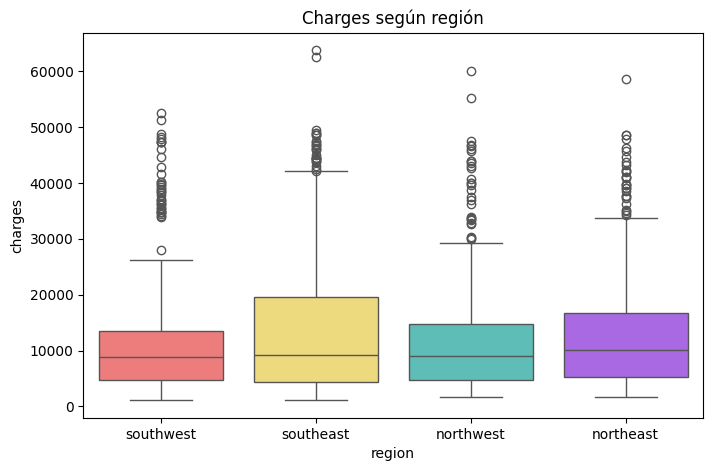

In [23]:
# precio por region
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=df,
            palette=['#FF6B6B', '#FFE66D', '#4ECDC4', '#A855F7'])
plt.title('Charges según región')
plt.show()

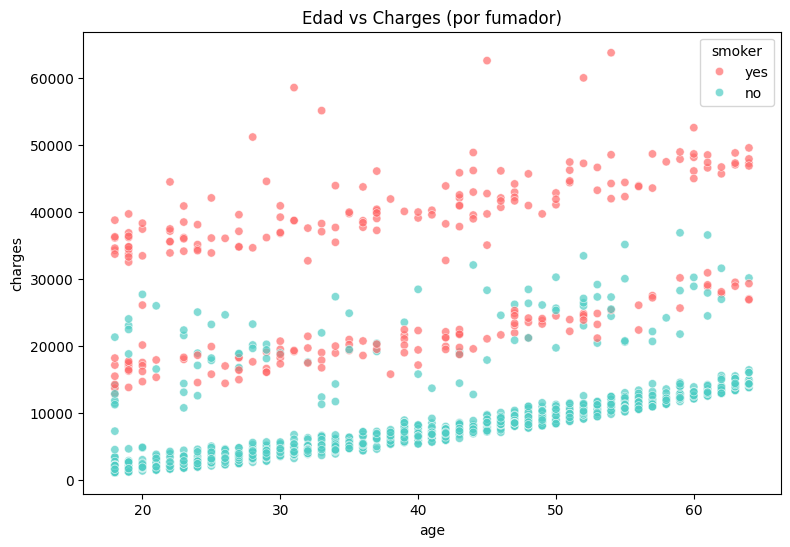

In [24]:
# relacion entre edad y precio, separando fumadores
plt.figure(figsize=(9, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df,
                palette={'yes': '#FF6B6B', 'no': '#4ECDC4'}, alpha=0.7)
plt.title('Edad vs Charges (por fumador)')
plt.show()

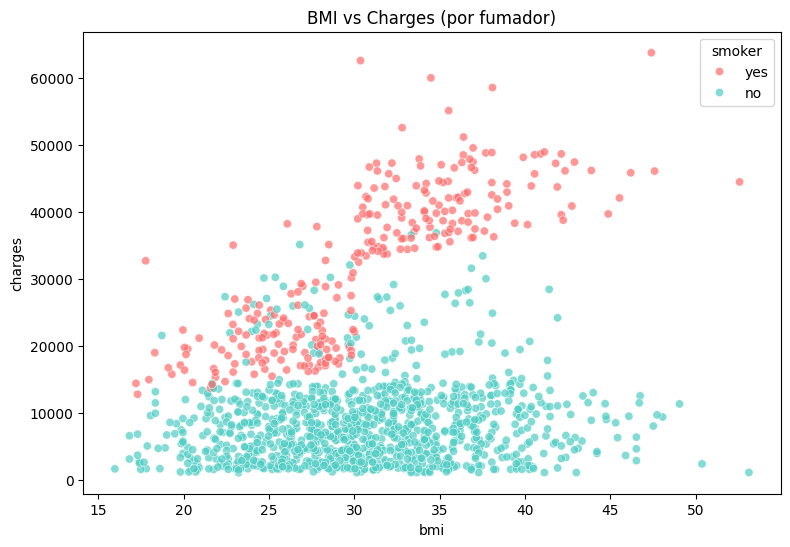

In [25]:
# relacion entre bmi y precio
plt.figure(figsize=(9, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df,
                palette={'yes': '#FF6B6B', 'no': '#4ECDC4'}, alpha=0.7)
plt.title('BMI vs Charges (por fumador)')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

# separo variables X e y
X = df.drop(columns='charges')
y = df['charges']

# divido en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1070 filas
Test:  268 filas


In [27]:
# paso 3: 
# convierto las columnas de texto a numeros con get_dummies
df_modelo = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_modelo.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [28]:
# separo lo que quiero predecir (y) del resto (X)
X = df_modelo.drop(columns='charges')
y = df_modelo['charges']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1070 filas
Test:  268 filas


In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado")


Modelo entrenado


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  4181.19
RMSE: 5796.28
R²:   0.7836


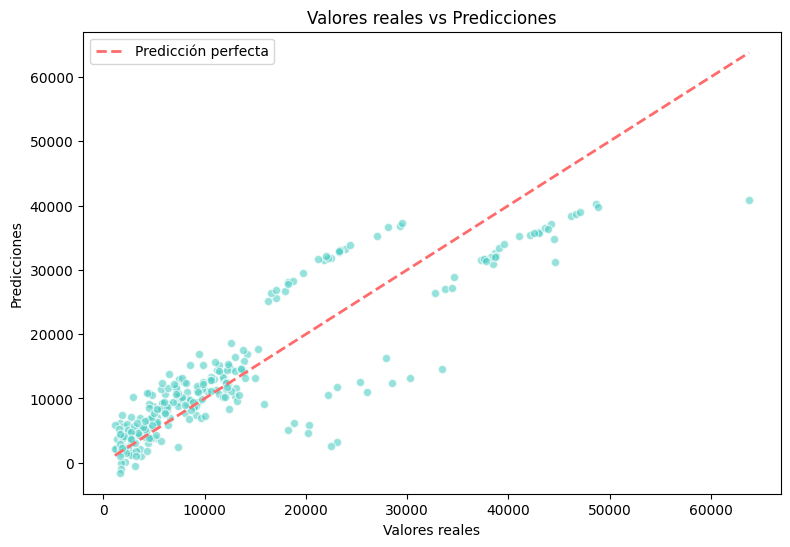

In [32]:
# grafico para ver que tan bien predice el modelo
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, color='#4ECDC4', alpha=0.6, edgecolor='white')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='#FF6B6B', linewidth=2, linestyle='--', label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Valores reales vs Predicciones')
plt.legend()
plt.show()

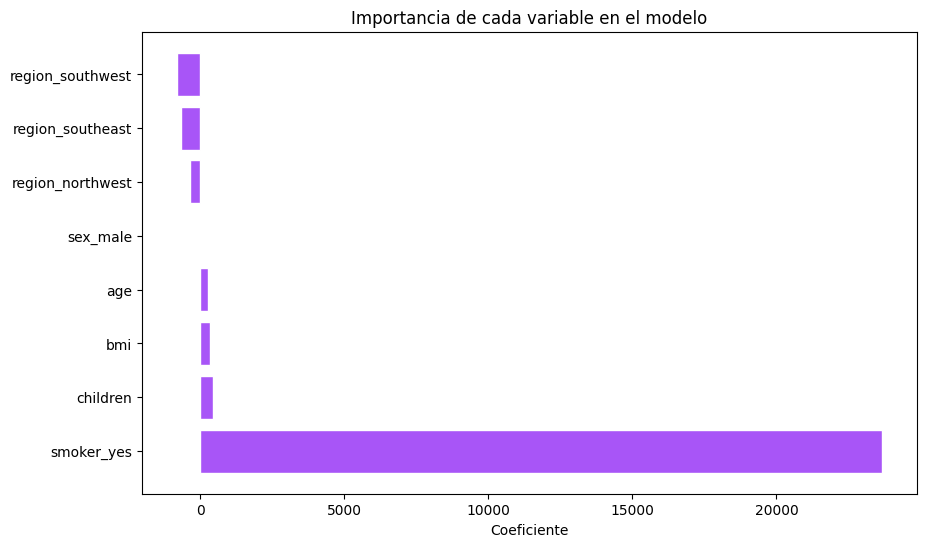

In [33]:
# que columnas influyen mas en el precio
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_
}).sort_values('coeficiente', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(coeficientes['variable'], coeficientes['coeficiente'],
         color='#A855F7', edgecolor='white')
plt.title('Importancia de cada variable en el modelo')
plt.xlabel('Coeficiente')
plt.show()

In [34]:
# paso 4
# creo una variable que combina bmi y ser fumador
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)

In [35]:
df_modelo2 = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X2 = df_modelo2.drop(columns='charges')
y2 = df_modelo2['charges']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [36]:
modelo2 = LinearRegression()
modelo2.fit(X_train2, y_train2)

print("Modelo mejorado entrenado")

Modelo mejorado entrenado


In [37]:
y_pred2 = modelo2.predict(X_test2)

mae2  = mean_absolute_error(y_test2, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_2  = r2_score(y_test2, y_pred2)

print("MODELO ORIGINAL:")
print(f"  R²: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")
print()
print("MODELO MEJORADO:")
print(f"  R²: {r2_2:.4f} | MAE: {mae2:.2f} | RMSE: {rmse2:.2f}")

MODELO ORIGINAL:
  R²: 0.7836 | MAE: 4181.19 | RMSE: 5796.28

MODELO MEJORADO:
  R²: 0.8653 | MAE: 2756.90 | RMSE: 4573.81


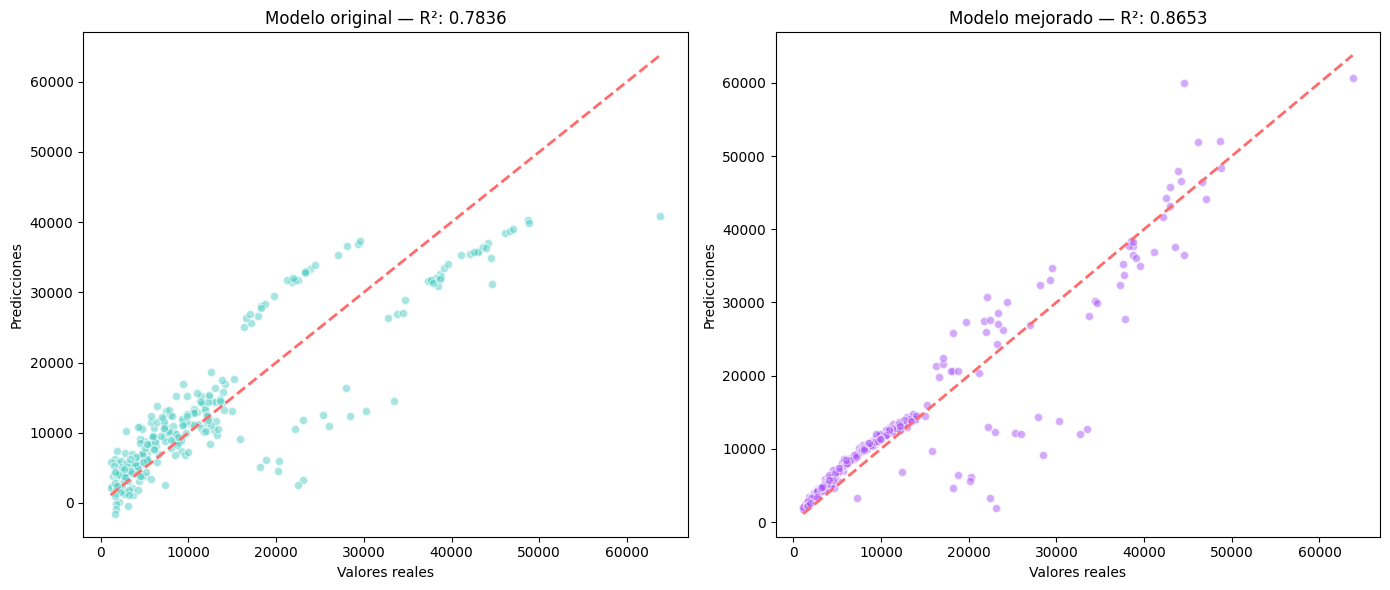

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred, color='#4ECDC4', alpha=0.5, edgecolor='white')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#FF6B6B', linewidth=2, linestyle='--')
axes[0].set_title(f'Modelo original — R²: {r2:.4f}')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Predicciones')

axes[1].scatter(y_test2, y_pred2, color='#A855F7', alpha=0.5, edgecolor='white')
axes[1].plot([y_test2.min(), y_test2.max()],
             [y_test2.min(), y_test2.max()],
             color='#FF6B6B', linewidth=2, linestyle='--')
axes[1].set_title(f'Modelo mejorado — R²: {r2_2:.4f}')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Predicciones')

plt.tight_layout()
plt.show()